<a href="https://colab.research.google.com/github/sandralungahi/Data-and-AI-mini-projects/blob/Exploratory_Data_Analysis/Used_Cars_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1: Data Parsing**

In [ ]:
# Import libraries
import pandas as pd
import re # imports the regex module

# Given data string
data = "brand: Ford, model: F-150, model_year: 2023, milage: 2,823 mi., price: 45000; brand: BMW, model: 740 iL, model_year: 2001, milage: 242,000 mi., price: 8500; brand: Tesla, model: Model X, model_year: 2020, milage: 34,000 mi., price: 75000"

# Step 1: Split by semicolon to separate each car record
records = [r.strip() for r in data.split(";") if r.strip()]

car_list = []

# Step 2: Extract details for each car using regex
for record in records:
    brand = re.search(r"brand:\s*([^,]+)", record)
    model = re.search(r"model:\s*([^,]+)", record)
    year = re.search(r"model_year:\s*(\d+)", record)
    milage = re.search(r"milage:\s*([\d,]+)", record)
    price = re.search(r"price:\s*(\d+)", record)

    car = {
        "brand": brand.group(1).strip() if brand else None,
        "model": model.group(1).strip() if model else None,
        "model_year": int(year.group(1)) if year else None,
        "milage_mi": int(milage.group(1).replace(",", "")) if milage else None,
        "price_usd": int(price.group(1)) if price else None
    }

    car_list.append(car)

# Step 3: Create a pandas DataFrame
df = pd.DataFrame(car_list)

# Step 4: Display the DataFrame
print(df)


   brand    model  model_year  milage_mi  price_usd
0   Ford    F-150        2023       2823      45000
1    BMW   740 iL        2001     242000       8500
2  Tesla  Model X        2020      34000      75000


**Part 2: Data wrangling and preparation**

In [ ]:
# Import libraries
import pandas as pd
import re
from datetime import datetime
from google.colab import files

# 1. Load dataset and display first 10 rows and structure
df = pd.read_csv("used_cars.csv")
print("First ten rows:\n", df.head(10))
print("\nDataset Info:\n")
df.info()

# 2. Clean 'milage' column
df['milage'] = df['milage'].str.replace(',', '', regex=False)
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False)
df['milage'] = df['milage'].astype(int)

# 3. Convert 'accident' column to boolean (True/False)
df['accident'] = df['accident'].str.contains('Yes|Reported|Accident', case=False, na=False)

# 4. Create 'car_age' column
current_year = 2025
df['car_age'] = current_year - df['model_year']

# 5. Extract 'horsepower' from 'engine' column using regex
def extract_hp(engine):
    if isinstance(engine, str):
        match = re.search(r'(\d+\.?\d*)\s*HP', engine)
        if match:
            return float(match.group(1))
    return None

df['horsepower'] = df['engine'].apply(extract_hp)

# Convert to numeric and fill NaN with median horsepower
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
median_hp = df['horsepower'].median()
df['horsepower'].fillna(median_hp, inplace=True)

# Clean the 'price' column: remove $ and commas, then convert to numeric
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows where price is missing
df = df.dropna(subset=['price'])

# Confirm it's fixed
print(df['price'].describe())

# Display cleaned dataset summary
print("\nCleaned Dataset Preview:\n", df.head())
print("\nUpdated Info:\n")
df.info()

# Save the cleaned dataset as a CSV File
df.to_csv('used_cars_cleaned.csv', index=False)


First ten rows:
       brand                            model  model_year       milage  \
0      Ford  Utility Police Interceptor Base        2013   51,000 mi.   
1   Hyundai                     Palisade SEL        2021   34,742 mi.   
2     Lexus                    RX 350 RX 350        2022   22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015   88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021    9,835 mi.   
5     Acura                         ILX 2.4L        2016  136,397 mi.   
6      Audi             S3 2.0T Premium Plus        2017   84,000 mi.   
7       BMW                           740 iL        2001  242,000 mi.   
8     Lexus                   RC 350 F Sport        2021   23,436 mi.   
9     Tesla          Model X Long Range Plus        2020   34,000 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                     

/tmp/ipython-input-3205893402.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(median_hp, inplace=True)


**Part 3: Exploratory Data Analysis**

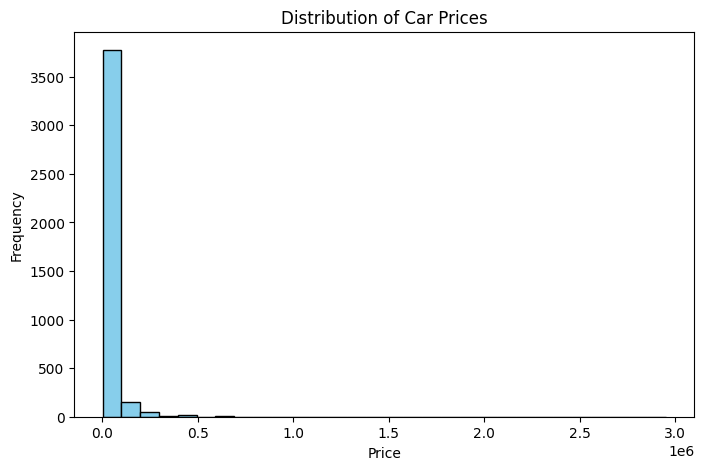

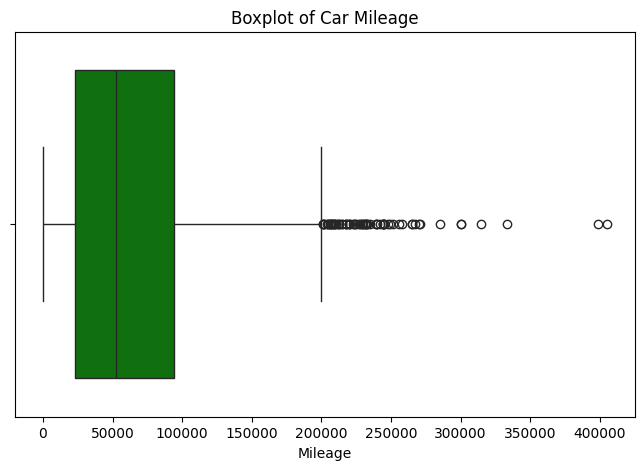

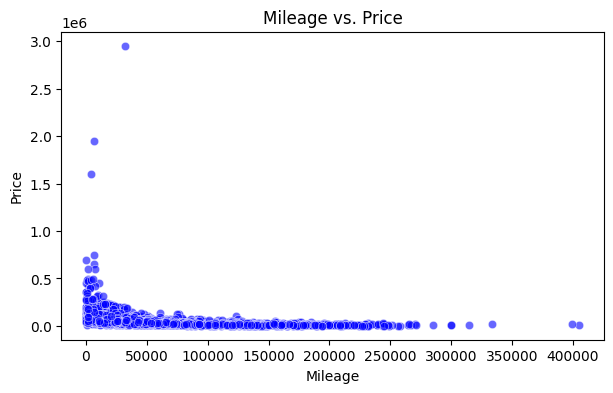

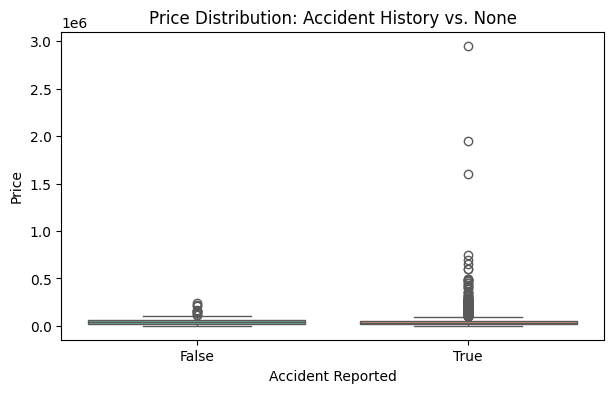

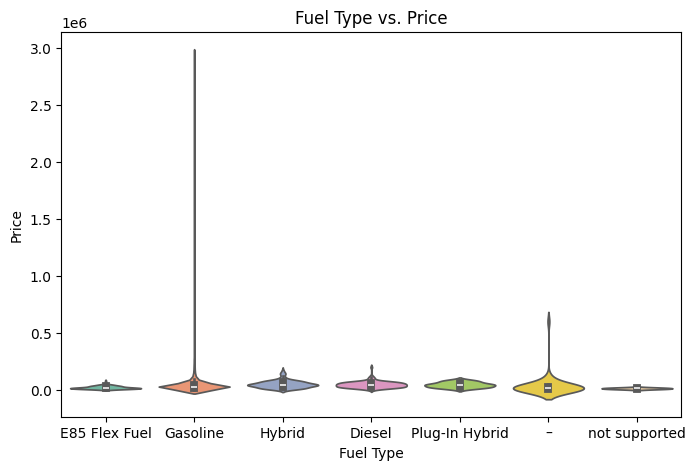

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load the cleaned dataset
df = pd.read_csv("used_cars_cleaned.csv")

# Ensure required columns are numeric
df['milage'] = df['milage'].replace({',': '', ' mi.': ''}, regex=True).astype(float)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 1. Univariate Analysis
# histogram to show the distribution of car price
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Boxplot to identify outliers in the milage column
plt.figure(figsize=(8,5))
sns.boxplot(x=df['milage'], color='green')
plt.title('Boxplot of Car Mileage')
plt.xlabel('Mileage')
plt.show()

# 2. Bivariate Analysis
# Scatter plot to visualize relationship between milage and price
plt.figure(figsize=(7,4))
sns.scatterplot(x='milage', y='price', data=df, color='blue', alpha=0.6)
plt.title('Mileage vs. Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

# a box plot to compare the distribution of price for cars with an accident history versus those with none.
plt.figure(figsize=(7,4))
sns.boxplot(x='accident', y='price', data=df, palette='Set2')
plt.title('Price Distribution: Accident History vs. None')
plt.xlabel('Accident Reported')
plt.ylabel('Price')
plt.show()

# violin plot showing the relationship between fuel type and price
plt.figure(figsize=(8,5))
sns.violinplot(x='fuel_type', y='price', data=df, palette='Set2')
plt.title('Fuel Type vs. Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()
